<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_034_column_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 34/365 — ColumnTransformer
## What if different columns need different preprocessing?

Yesterday we encoded categorical features. Real datasets usually mix numerical and categorical columns.

Today we use **ColumnTransformer** so numerical columns can be scaled while categorical columns are one-hot encoded inside the same workflow.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 1. Create a mixed-type housing dataset


In [2]:
rng = np.random.default_rng(42)
n = 400
area = rng.integers(500, 2500, size=n)
age = rng.integers(0, 40, size=n)
city = rng.choice(['Delhi', 'Pune', 'Dehradun'], size=n)

city_effect = {'Delhi': 30, 'Pune': 18, 'Dehradun': 10}

price = (
    12
    + 0.04 * area
    - 0.7 * age
    + np.array([city_effect[c] for c in city])
    + rng.normal(0, 5, size=n)
)

df = pd.DataFrame({
    'area': area,
    'age': age,
    'city': city,
    'price': price
})

display(df.head())


,area,age,city,price
0,678,39,Delhi,48.059750
1,2047,31,Delhi,100.917413
2,1809,12,Pune,95.777272
3,1377,38,Dehradun,38.430390
4,1366,19,Dehradun,57.558262


## 2. Split the data


In [3]:
X = df[['area', 'age', 'city']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


## 3. Apply different preprocessing to different columns


In [4]:
numeric_features = ['area', 'age']
categorical_features = ['city']

preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## 4. Combine preprocessing and model in one Pipeline


In [5]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print('Test RMSE:', round(rmse, 2))
print('Test R2:', round(r2, 3))


Test RMSE: 4.92
Test R2: 0.967


## 5. Inspect what the model actually receives


In [6]:
sample = X_train.head(5)

transformed = pipeline.named_steps['preprocessor'].transform(sample)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

transformed_df = pd.DataFrame(
    transformed,
    columns=feature_names,
    index=sample.index
)

print('Raw input:')
display(sample)

print('After ColumnTransformer:')
display(transformed_df.round(3))


Raw input:


,area,age,city
3,1377,38,Dehradun
18,2179,11,Pune
202,1490,29,Pune
250,858,19,Pune
274,1336,24,Pune


After ColumnTransformer:


,numeric__area,numeric__age,categorical__city_Dehradun,categorical__city_Delhi,categorical__city_Pune
3,-0.227,1.514,1.0,0.0,0.0
18,1.218,-0.778,0.0,0.0,1.0
202,-0.024,0.750,0.0,0.0,1.0
250,-1.163,-0.099,0.0,0.0,1.0
274,-0.301,0.326,0.0,0.0,1.0


## 6. Visualize actual vs predicted values


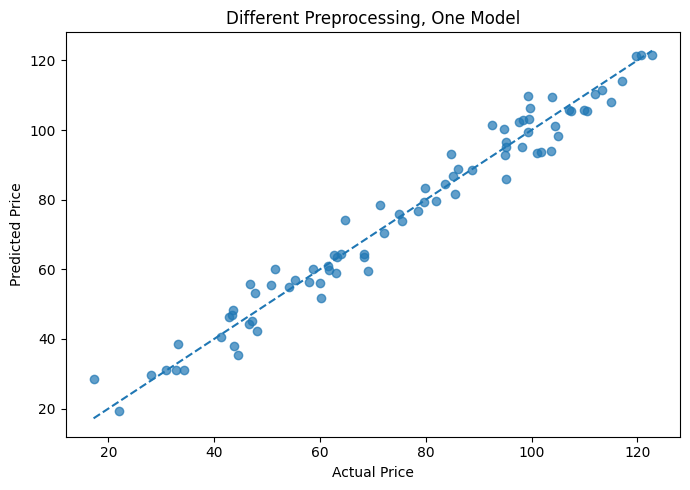

In [7]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions, alpha=0.7)

low = min(y_test.min(), predictions.min())
high = max(y_test.max(), predictions.max())
plt.plot([low, high], [low, high], linestyle='--')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Different Preprocessing, One Model')
plt.tight_layout()
plt.show()


## What does this experiment teach?

- Different feature types often need different preprocessing.
- **StandardScaler** can be applied only to numerical columns.
- **OneHotEncoder** can be applied only to categorical columns.
- **ColumnTransformer** combines everything into one model-ready matrix.
- Putting it inside a **Pipeline** keeps training and inference consistent.
- `handle_unknown='ignore'` helps with unseen categories at inference.

> **One dataset does not mean one preprocessing rule.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
- https://scikit-learn.org/stable/modules/compose.html#columntransformer-for-heterogeneous-data
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
